# Setup and data loading


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [2]:
# load dataset
data_path="../data/raw_nsw_coast_data_2016_2021.xlsx"
df=pd.read_excel(data_path,
                 sheet_name="2016 to 2021 data")
df.head()


,Number,Station,Catchment,Zone,Time stamp (Sampling),Electrical Conductivity @25 C / WCK - Determination of Conductivity in Water [µS/cm],Nitrogen - total / WCK - Simultaneous Determination of Total Nitrogen and Total Phosphorus using Persulphate Digestion [mg/L],Nitrate + nitrite as N (NOx) / WCK - Determination of Oxidised Nitrogen Nitrate & Nitrite in Water [mg/L],Phosphorus - total / WCK - Simultaneous Determination of Total Nitrogen and Total Phosphorus using Persulphate Digestion [mg/L],Phosphorus - reactive (orthophosphate) - dissolved / WCK - Determination of Reactive Phosphorus [mg/L],Solids - total suspended @ 105 C / WCK - Total Suspended Solids at 105°C [mg/L],Turbidity / Field - Determination of turbidity by nephelometry using HACH turbidimeter [NTU],Oxygen - dissolved saturation / Field - Water quality sonde [% sat],pH / Field - Water quality sonde [---]
0,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-06-28 11:45:00,230.0,1.10,0.42,0.240,0.140,13.0,34.0,NaN,NaN
1,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-08-18 12:27:00,260.0,0.52,0.19,0.150,0.110,10.0,16.9,108.0,7.8
2,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-09-29 11:18:00,340.0,0.36,0.01,0.099,0.068,10.0,5.4,101.0,8.1
3,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-10-26 10:21:00,350.0,0.22,0.01,0.088,0.068,10.0,5.7,112.0,8.3
4,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-11-29 08:57:00,330.0,0.28,0.01,0.140,0.120,10.0,6.8,119.0,8.2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1484 entries, 0 to 1483
Data columns (total 14 columns):
 #   Column                                                                                                                           Non-Null Count  Dtype         
---  ------                                                                                                                           --------------  -----         
 0   Number                                                                                                                           1484 non-null   int64         
 1   Station                                                                                                                          1484 non-null   str           
 2   Catchment                                                                                                                        1484 non-null   str           
 3   Zone                                                                      

#### This is a relatively clean dataset with 1484 rows,14 columns and low missing values. 
#### sincee the column names are very long, we rename the columns 

In [6]:
df.columns = [
    "number",
    "station",
    "catchment",
    "zone",
    "sample_date",
    "ec_us_cm",          # Electrical Conductivity
    "total_n_mg_l",      # Total Nitrogen
    "nox_n_mg_l",        # Nitrate + Nitrite as N
    "total_p_mg_l",      # Total Phosphorus
    "reactive_p_mg_l",   # Reactive Phosphorus (orthophosphate)
    "tss_mg_l",          # Total Suspended Solids
    "turbidity_ntu",     # Turbidity
    "do_sat_pct",        # Dissolved Oxygen % saturation
    "ph"                 # pH
]

df.head()

,number,station,catchment,zone,sample_date,ec_us_cm,total_n_mg_l,nox_n_mg_l,total_p_mg_l,reactive_p_mg_l,tss_mg_l,turbidity_ntu,do_sat_pct,ph
0,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-06-28 11:45:00,230.0,1.10,0.42,0.240,0.140,13.0,34.0,NaN,NaN
1,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-08-18 12:27:00,260.0,0.52,0.19,0.150,0.110,10.0,16.9,108.0,7.8
2,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-09-29 11:18:00,340.0,0.36,0.01,0.099,0.068,10.0,5.4,101.0,8.1
3,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-10-26 10:21:00,350.0,0.22,0.01,0.088,0.068,10.0,5.7,112.0,8.3
4,203004,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-11-29 08:57:00,330.0,0.28,0.01,0.140,0.120,10.0,6.8,119.0,8.2


In [7]:
## adding time features such as year and month by extracting from sample_date column
df["year"] = df["sample_date"].dt.year
df["month"] = df["sample_date"].dt.month

def get_season(m):
    if m in [12, 1, 2]: return "summer"
    if m in [3, 4, 5]:  return "autumn"
    if m in [6, 7, 8]:  return "winter"
    return "spring"

df["season"] = df["month"].apply(get_season)

In [8]:
#check new columns now
df.columns

Index(['number', 'station', 'catchment', 'zone', 'sample_date', 'ec_us_cm', 'total_n_mg_l', 'nox_n_mg_l',
       'total_p_mg_l', 'reactive_p_mg_l', 'tss_mg_l', 'turbidity_ntu', 'do_sat_pct', 'ph', 'year', 'month', 'season'],
      dtype='str')

/var/folders/02/v225726j2rqdwt7yggx1jw4c0000gn/T/ipykernel_19972/175150409.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values * 100, y=missing.index, palette="Reds_r")


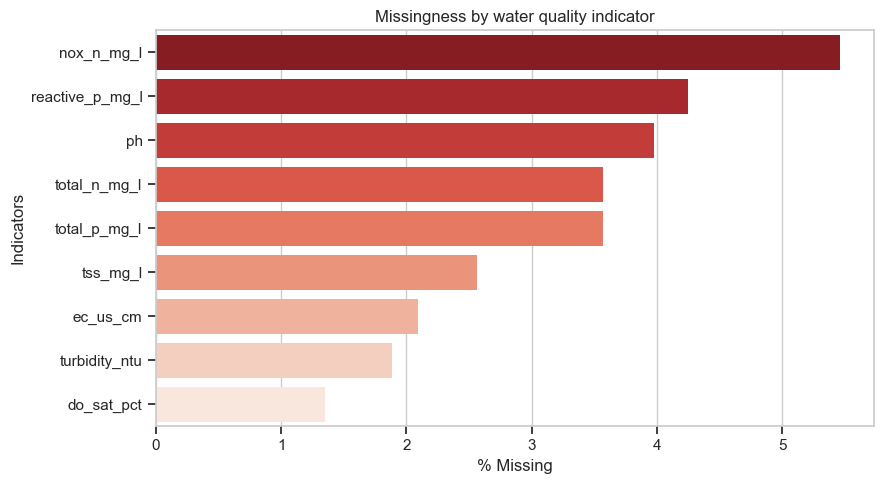

nox_n_mg_l         5.458221
reactive_p_mg_l    4.245283
ph                 3.975741
total_n_mg_l       3.571429
total_p_mg_l       3.571429
tss_mg_l           2.560647
ec_us_cm           2.088949
turbidity_ntu      1.886792
do_sat_pct         1.347709
dtype: float64


In [9]:
### we check percentage of missing values in indicator columns
indicator_cols = [
    "ec_us_cm", "total_n_mg_l", "nox_n_mg_l",
    "total_p_mg_l", "reactive_p_mg_l", "tss_mg_l",
    "turbidity_ntu", "do_sat_pct", "ph"
]

missing = df[indicator_cols].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=missing.values * 100, y=missing.index, palette="Reds_r")
plt.xlabel("% Missing")
plt.ylabel("Indicators")
plt.title("Missingness by water quality indicator")
plt.tight_layout()
plt.savefig("../figures/01_missingness.png", dpi=150)
plt.show()

print(missing * 100)

#### Since all indicators have less than 7% missing values, we donot need to drop columns. We will impute missing values using median per station at the ML Modelling Part of the project

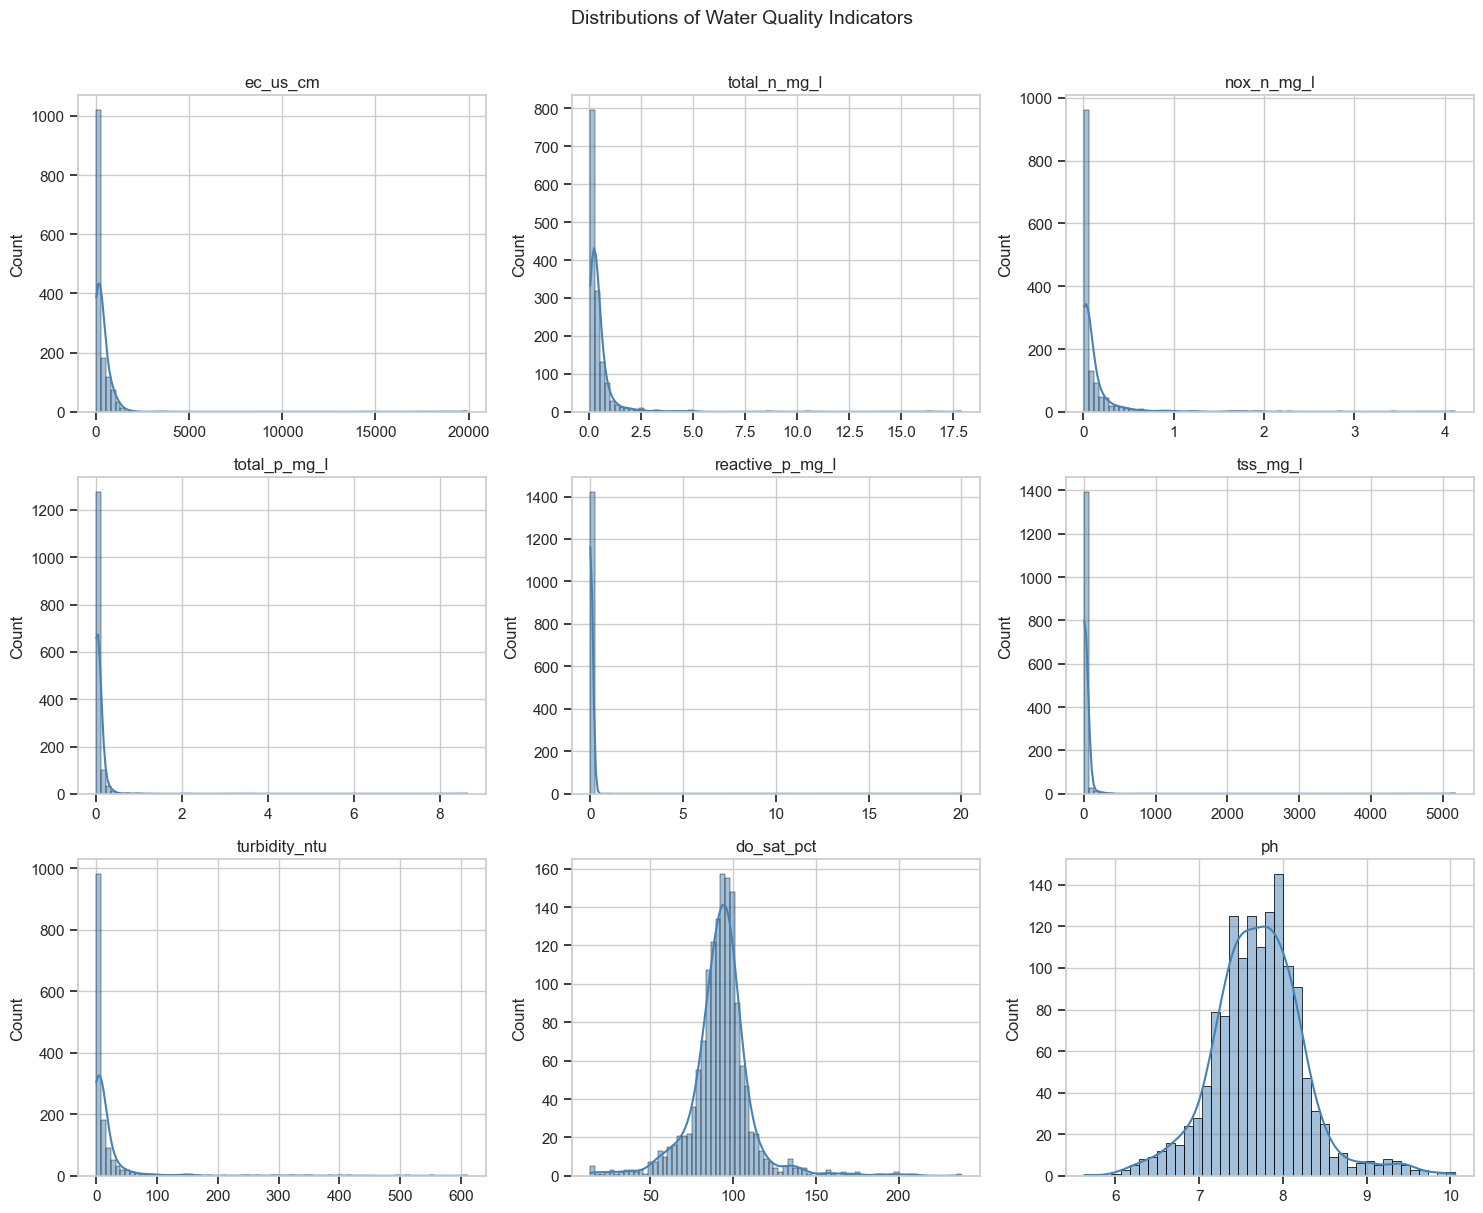

In [10]:
# Univariate Distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(indicator_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Distributions of Water Quality Indicators", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/02_univariate_distributions.png", dpi=150)
plt.show()

#### The univariate analysis shows that 'ec_us_cm', 'total_n_mg_l', 'nox_n_mg_l', 'total_p_mg_l', 'reactive_p_mg_l', 'tss_mg_l', 'turbidity_ntu' are right skewed and  'do_sat_pct', 'ph' are normally distributed. The right skewed indicators are candidates for log transform in ML modelling section. 

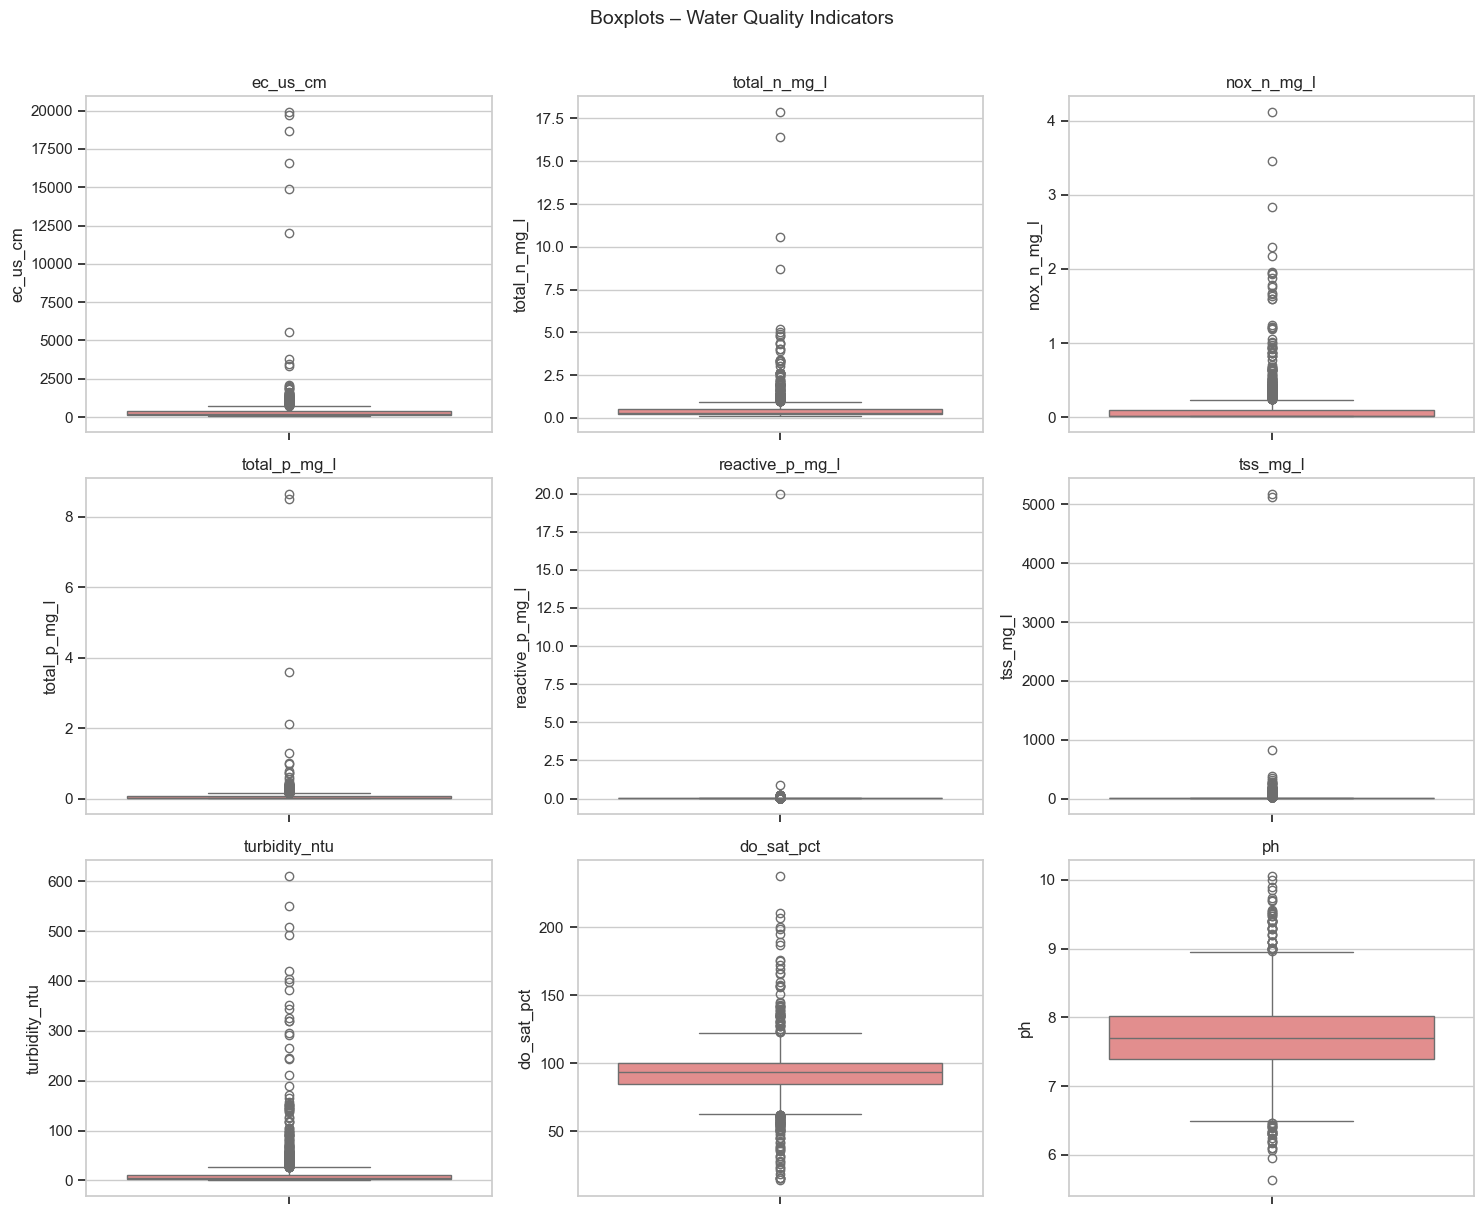

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(indicator_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="lightcoral")
    axes[i].set_title(col)

plt.suptitle("Boxplots – Water Quality Indicators", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/03_boxplots.png", dpi=150)
plt.show()

In [13]:
# SUmmary stats table
summary = df[indicator_cols].describe().T.round(3)
summary["missing_%"] = (df[indicator_cols].isna().mean() * 100).round(2)
summary.to_csv("../figures/04_summary_stats.csv")
summary

,count,mean,std,min,25%,50%,75%,max,missing_%
ec_us_cm,1453.0,385.057,1143.706,38.400,120.000,180.000,371.700,19934.00,2.09
total_n_mg_l,1431.0,0.495,0.912,0.080,0.200,0.300,0.500,17.90,3.57
nox_n_mg_l,1403.0,0.113,0.282,0.010,0.010,0.020,0.100,4.12,5.46
total_p_mg_l,1431.0,0.073,0.348,0.010,0.010,0.029,0.070,8.65,3.57
reactive_p_mg_l,1421.0,0.036,0.531,0.005,0.010,0.010,0.020,20.00,4.25
tss_mg_l,1446.0,24.560,194.830,5.000,5.000,10.000,11.000,5180.00,2.56
turbidity_ntu,1456.0,16.647,47.707,0.020,1.908,3.950,11.600,611.00,1.89
do_sat_pct,1464.0,92.586,19.439,13.700,85.000,93.200,100.025,238.00,1.35
ph,1425.0,7.713,0.556,5.630,7.400,7.700,8.020,10.06,3.98


In [14]:
# Per catchment and per station overview
print("Unique catchments:", df["catchment"].nunique())
print("Unique stations:", df["station"].nunique())
print("Unique zones:", df["zone"].nunique())
print("\nSamples per catchment:\n", df["catchment"].value_counts())

Unique catchments: 15
Unique stations: 27
Unique zones: 6

Samples per catchment:
 catchment
Hunter       390
Clarence     161
Bega         113
Karuah       112
Manning      109
Richmond     105
Tweed         56
Macleay       55
Bellinger     55
Hastings      55
Clyde         55
Tuross        55
Towamba       55
Moruya        54
Snowy         54
Name: count, dtype: int64


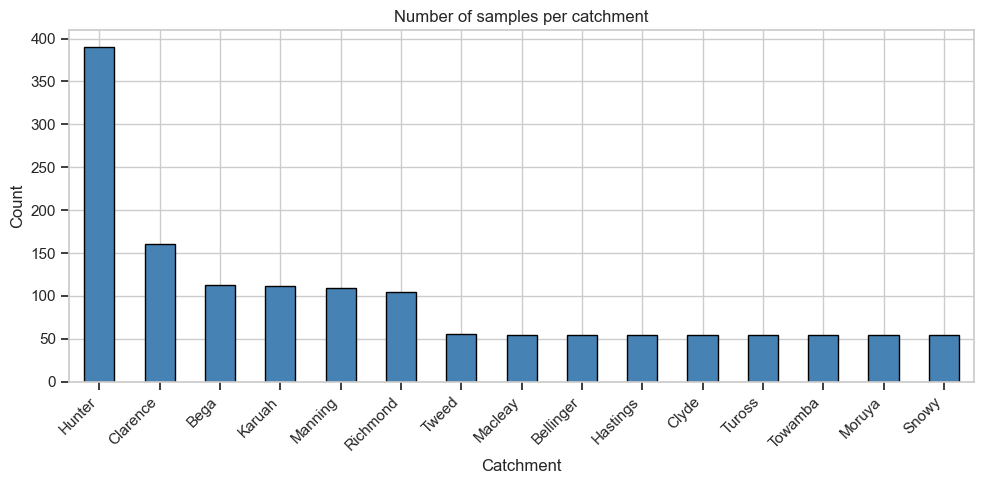

In [15]:
## plotting number of samples per catchment
plt.figure(figsize=(10, 5))
df["catchment"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Number of samples per catchment")
plt.xlabel("Catchment")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/05_samples_per_catchment.png", dpi=150)
plt.show()

#### Looking at the plot it is clear that the sampling is very uneven since Hunter has 390 samples, Clarence has 161 and the rest cluster around 50-110. 

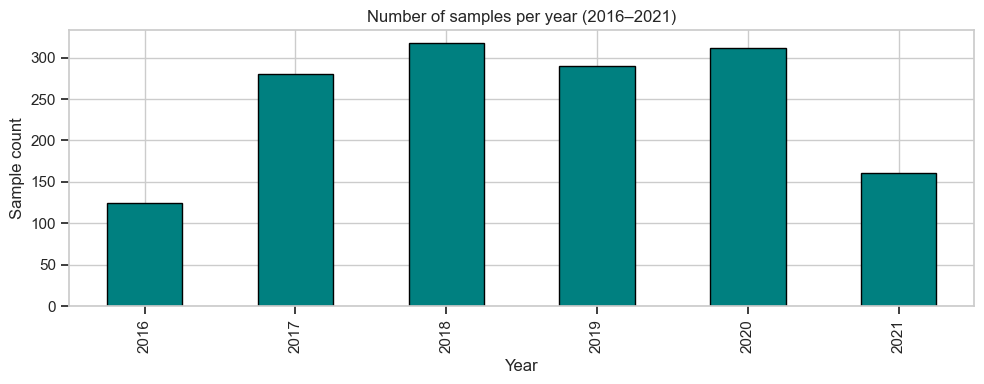

In [16]:
# plotting number of samples per year
plt.figure(figsize=(10, 4))
df.groupby("year").size().plot(kind="bar", color="teal", edgecolor="black")
plt.title("Number of samples per year (2016–2021)")
plt.xlabel("Year")
plt.ylabel("Sample count")
plt.tight_layout()
plt.savefig("../figures/06_samples_per_year.png", dpi=150)
plt.show()

# Bivariate Analysis


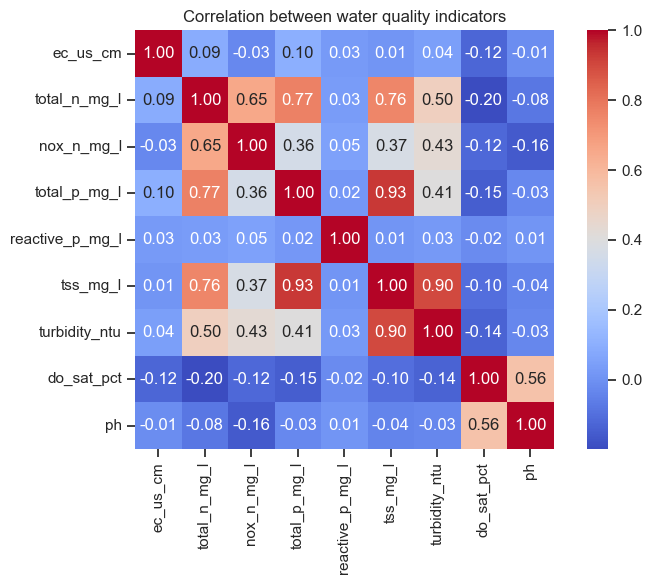

In [17]:
# Correlation matrix
indicator_cols = [
    "ec_us_cm", "total_n_mg_l", "nox_n_mg_l",
    "total_p_mg_l", "reactive_p_mg_l", "tss_mg_l",
    "turbidity_ntu", "do_sat_pct", "ph"
]

corr = df[indicator_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation between water quality indicators")
plt.tight_layout()
plt.savefig("../figures/07_corr_matrix.png", dpi=150)
plt.show()

## What is the correlation matrix saying???
1 : total_n_mg_l and total_p_mg_l are quite strongly correlated with each other and with tss_mg_l and turbidity_ntu 


2:: nox_n_mg_l has a strong positive link with total_n_mg_l and a moderate link with total_p_mg_l
>>this is in line with the expectation that nutrient and suspeneded sediment indicators tend to rise together in runoff events.

3 : ec_us_cm is weakly corelated with other variables which means it captures different water quality aspect.
4: tss_mg_l and turbidity_ntu have a very high correlation (around 0.9) which means sediment indicators are tightly linked so they are most likely measuring the same "suspended solids" phenomenon.
 

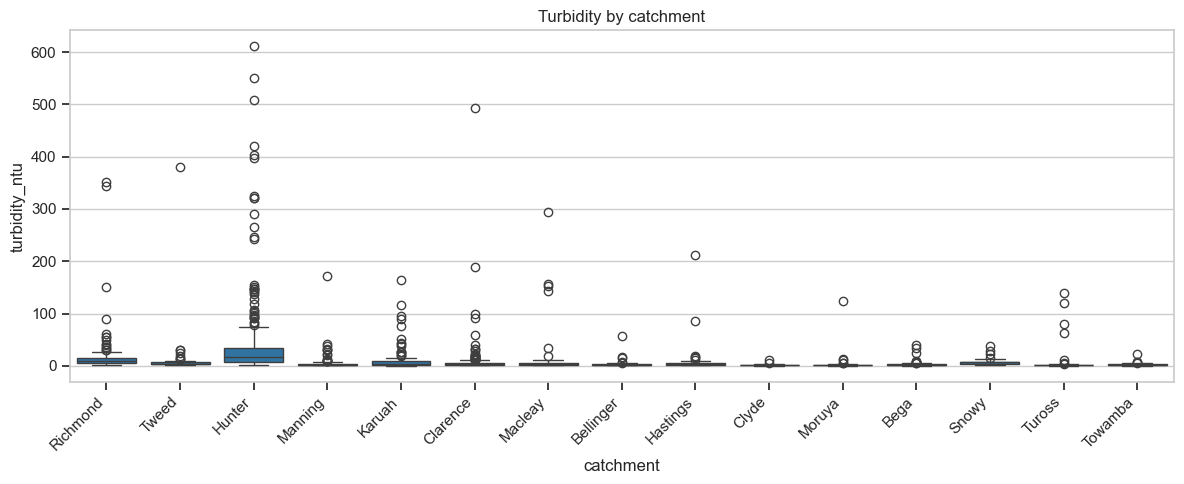

In [15]:
#Indicator distributions by catchment
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="catchment", y="turbidity_ntu")
plt.xticks(rotation=45, ha="right")
plt.title("Turbidity by catchment")
plt.tight_layout()
plt.savefig("../figures/08_turbidity_by_catchment.png", dpi=150)
plt.show()

## Calculation of high_concern label
#### since nutrients and sediments tend to cluster together, we can define a risk label which is based on 
 >> 1 High Turbidity/ TSS (based on event conditions)
 >> High total N/total p(nutrient enrichment)
 >> Low value of DO saturation(oxygen stress)

#### so in next few steps we will
 >> 1 compute percentil(90th) e for turbidiy, TSS,total N ,total P


 >> 2 flag samples which are above those percentiles as "high" for eaach indicator


 >> 3 flag samples having do_sat_pct indicator below a lowe percentile(10th) as "low DO"


 >>4 if the sample has atleast 2 bad flags(egg highT TSS or high turbidity or low DO) then high_concern=1 is defined otherwise high concern = 0

 The key concept for this is :
 if a sample shows multiple stress signals then it is classified as high concern. The stress signals could be any of the follows:


 >> Very High TSS or turbidity( lots of suspended material -->> poor clarity)


 >> very high nutrients (total N or total P) indicate eutrophication risk


 >> vert low dissolved oxygen(DO) indicates stress for aquatic life 

In [20]:
### defining high concern labels and assigning percentiles 
# Choose indicators for risk
risk_indicators = {
    "turbidity_ntu": "high",
    "tss_mg_l": "high",
    "total_n_mg_l": "high",
    "total_p_mg_l": "high",
    "do_sat_pct": "low",
}

# Choose percentiles
high_percentile = 0.9   # 90th percentile for "high"
low_percentile = 0.1    # 10th percentile for "low" DO (more conservative)

thresholds = {}

for col, direction in risk_indicators.items():
    if direction == "high":
        thr = df[col].quantile(high_percentile)
    else:  # "low"
        thr = df[col].quantile(low_percentile)
    thresholds[col] = {"direction": direction, "threshold": thr}

thresholds 


{'turbidity_ntu': {'direction': 'high', 'threshold': np.float64(32.95)},
 'tss_mg_l': {'direction': 'high', 'threshold': np.float64(32.0)},
 'total_n_mg_l': {'direction': 'high', 'threshold': np.float64(0.9)},
 'total_p_mg_l': {'direction': 'high', 'threshold': np.float64(0.13)},
 'do_sat_pct': {'direction': 'low', 'threshold': np.float64(73.5)}}

In [21]:
## creating the bad flag indicator 
for col, info in thresholds.items():
    direction = info["direction"]
    thr = info["threshold"]
    flag_col = f"{col}_bad"

    if direction == "high":
        df[flag_col] = (df[col] >= thr).astype(int)
    else:  # low
        df[flag_col] = (df[col] <= thr).astype(int)

bad_flag_cols = [f"{col}_bad" for col in risk_indicators.keys()]

df[bad_flag_cols].sum()

turbidity_ntu_bad    146
tss_mg_l_bad         147
total_n_mg_l_bad     155
total_p_mg_l_bad     156
do_sat_pct_bad       148
dtype: int64

In [22]:
#risk score = number of "bad" indicators in this sample
df["risk_score"] = df[bad_flag_cols].sum(axis=1)

#labelling high_concern if at least 2 indicators are bad
df["high_concern"] = (df["risk_score"] >= 2).astype(int)

df["high_concern"].value_counts(normalize=True).round(3)

high_concern
0    0.883
1    0.117
Name: proportion, dtype: float64

/var/folders/02/v225726j2rqdwt7yggx1jw4c0000gn/T/ipykernel_19972/2354612099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="risk_score", data=df, palette="viridis")


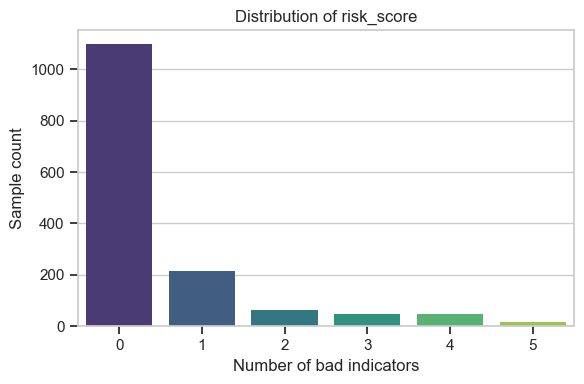

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x="risk_score", data=df, palette="viridis")
plt.title("Distribution of risk_score")
plt.xlabel("Number of bad indicators")
plt.ylabel("Sample count")
plt.tight_layout()
plt.savefig("../figures/09_risk_score_distribution.png", dpi=150)
plt.show()

#### What the plot says?
The chart indicates that most samples have risk score of 0, which means none of the key indicators are in "bad" range at the same time. 

SMall number of samples have scores of 1 and 2 and very few have scores of 3,4,5. This indicates that multiple indicator stress levels are very less but they are present in the dataset


This justifies using high_concern of 2 or more bad indicators to actually focus on actually problematic samples ranther than minor outliers. 

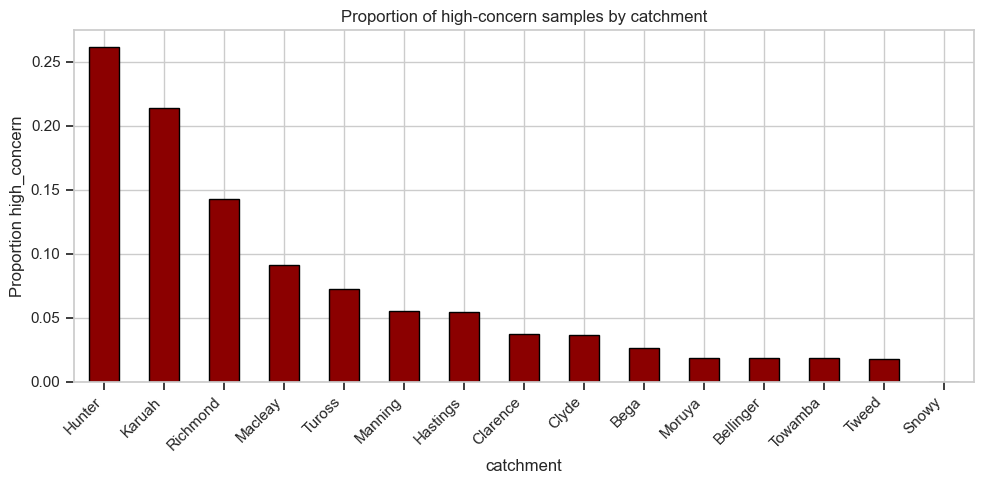

catchment
Hunter       0.261538
Karuah       0.214286
Richmond     0.142857
Macleay      0.090909
Tuross       0.072727
Manning      0.055046
Hastings     0.054545
Clarence     0.037267
Clyde        0.036364
Bega         0.026549
Moruya       0.018519
Bellinger    0.018182
Towamba      0.018182
Tweed        0.017857
Snowy        0.000000
Name: high_concern, dtype: float64

In [24]:
catchment_risk = (
    df.groupby("catchment")["high_concern"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
catchment_risk.plot(kind="bar", color="darkred", edgecolor="black")
plt.ylabel("Proportion high_concern")
plt.title("Proportion of high-concern samples by catchment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/10_high_concern_by_catchment.png", dpi=150)
plt.show()

catchment_risk

# What the plot says?
Hunter and karuah are the catchment with most proportion of high concern samples followed by richmond and macleay. Several other catchments such as snowy,twee,towamba,bellinger,moruya have very low proportions of high concern samples which suggests better water quality under this index.

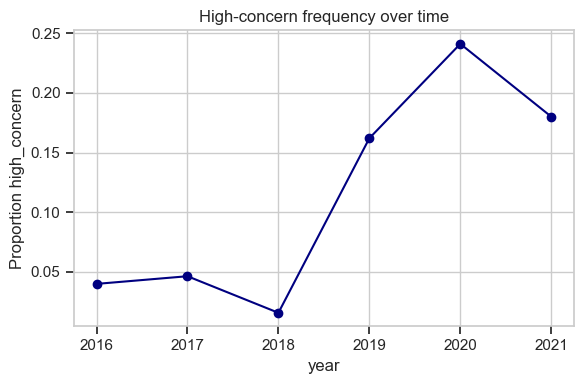

year
2016    0.040000
2017    0.046429
2018    0.015773
2019    0.162069
2020    0.241158
2021    0.180124
Name: high_concern, dtype: float64

In [25]:
year_risk = df.groupby("year")["high_concern"].mean()

plt.figure(figsize=(6, 4))
year_risk.plot(marker="o", color="navy")
plt.ylabel("Proportion high_concern")
plt.title("High-concern frequency over time")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/11_high_concern_over_time.png", dpi=150)
plt.show()

year_risk

# What the plot says, 
between 2016 and 2018 the proportion of high concern samples were fairly stable but there was a sharp increase from 2018 to 2019 and it peaked around 2020 followed by slight decline in 2021.

In [26]:
# save the dataset for modelling
modelling_cols = [
    "station", "catchment", "zone",
    "sample_date", "year", "month", "season",
] + indicator_cols + ["risk_score", "high_concern"] + bad_flag_cols

df_mod = df[modelling_cols].copy()
df_mod.to_csv("../data/wq_modelling.csv", index=False)

df_mod.head()

,station,catchment,zone,sample_date,year,month,season,ec_us_cm,total_n_mg_l,nox_n_mg_l,total_p_mg_l,reactive_p_mg_l,tss_mg_l,turbidity_ntu,do_sat_pct,ph,risk_score,high_concern,turbidity_ntu_bad,tss_mg_l_bad,total_n_mg_l_bad,total_p_mg_l_bad,do_sat_pct_bad
0,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-06-28 11:45:00,2016,6,winter,230.0,1.10,0.42,0.240,0.140,13.0,34.0,NaN,NaN,3,1,1,0,1,1,0
1,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-08-18 12:27:00,2016,8,winter,260.0,0.52,0.19,0.150,0.110,10.0,16.9,108.0,7.8,1,0,0,0,0,1,0
2,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-09-29 11:18:00,2016,9,spring,340.0,0.36,0.01,0.099,0.068,10.0,5.4,101.0,8.1,0,0,0,0,0,0,0
3,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-10-26 10:21:00,2016,10,spring,350.0,0.22,0.01,0.088,0.068,10.0,5.7,112.0,8.3,0,0,0,0,0,0,0
4,RICHMOND RIVER AT CASINO,Richmond,Far North Coast,2016-11-29 08:57:00,2016,11,spring,330.0,0.28,0.01,0.140,0.120,10.0,6.8,119.0,8.2,1,0,0,0,0,1,0
